In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
ds=pd.read_csv("spam.csv",encoding="latin-1")

In [3]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
ds.shape

(5572, 5)

In [5]:
#1.Cleaning
#2.EDA
##text Preprocessing
#4.Model Build
#5. Evaluation 
#6.improvement
#7.website

In [6]:
#1.cleaning
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
ds.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)

In [8]:
ds.sample(5)

,v1,v2
1217,ham,"Damn, can you make it tonight or do you want t..."
4006,ham,I'm reaching home in 5 min.
5244,ham,thanks for the temales it was wonderful. Thank...
1609,ham,You all ready for * big day tomorrow?
4205,ham,"Get the door, I'm here"


In [9]:
ds.rename(columns={"v1":"Target","v2":"Text"},inplace=True)

In [10]:
ds.sample(5)

,Target,Text
1308,ham,I jokin oni lar.. ÌÏ busy then i wun disturb Ì_.
4238,ham,"Sez, hows u & de arab boy? Hope u r all good g..."
5321,ham,Ok no problem... Yup i'm going to sch at 4 if ...
2210,ham,Just wanted to say holy shit you guys weren't ...
2751,ham,Play w computer? Aiyah i tok 2 u lor?


In [11]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [12]:
ds["Target"]=encoder.fit_transform(ds["Target"])

In [13]:
ds.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
#Missing value
ds.isnull().sum()

Target    0
Text      0
dtype: int64

In [15]:
#Dubplicate value
ds.duplicated().sum()

403

In [16]:
ds=ds.drop_duplicates(keep="first")

In [17]:
ds.duplicated().sum()

0

In [18]:
ds.shape


(5169, 2)

In [19]:
#2.EDA


In [20]:
ds["Target"].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

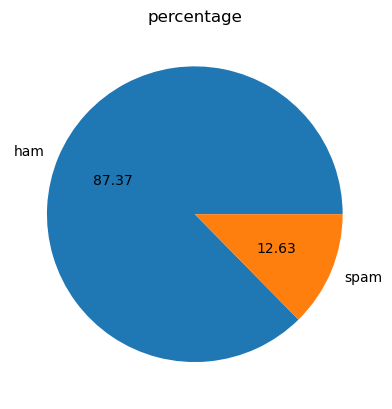

In [21]:
plt.pie(ds["Target"].value_counts(),labels=("ham","spam"),autopct="%.2f")
plt.title("percentage")
plt.show()

In [22]:
import nltk
#pip install nltk

In [23]:
nltk.download("punkt")

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [24]:
nltk.download('punkt_tab')

[nltk_data] Error loading punkt_tab: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [25]:
ds["num_character"]=ds["Text"].apply(len)

In [26]:
ds.head()

,Target,Text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [27]:
#The num of words
ds["Text"].apply(lambda x:nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: Text, Length: 5169, dtype: object

In [28]:
ds['num_words']=ds['Text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [29]:
ds.head()

,Target,Text,num_character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [30]:
ds['num_sentence']=ds['Text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [31]:
ds.head()

,Target,Text,num_character,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [32]:
ds[['num_character','num_words','num_sentence']].describe()

,num_character,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [33]:
#ham
ds[ds['Target']==0][['num_character','num_words','num_sentence']].describe()

,num_character,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [34]:
#spam
ds[ds['Target']==1][['num_character','num_words','num_sentence']].describe()

,num_character,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


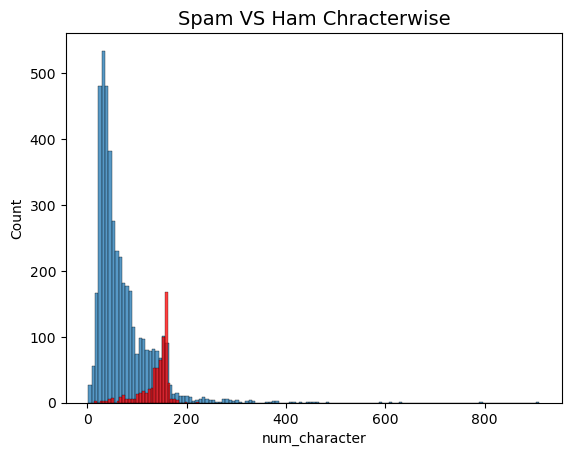

In [35]:
sns.histplot(ds[ds['Target']==0]['num_character'])
sns.histplot(ds[ds['Target']==1]['num_character'],color='red')
plt.title("Spam VS Ham Chracterwise",fontsize=14)
plt.show()

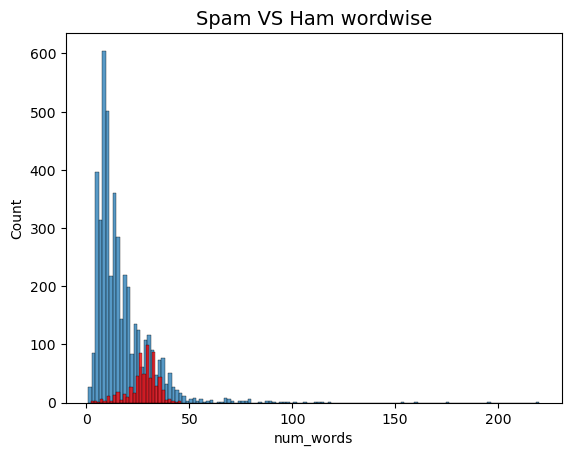

In [36]:
sns.histplot(ds[ds['Target']==0]['num_words'])
sns.histplot(ds[ds['Target']==1]['num_words'],color='red')
plt.title("Spam VS Ham wordwise",fontsize=14)
plt.show()

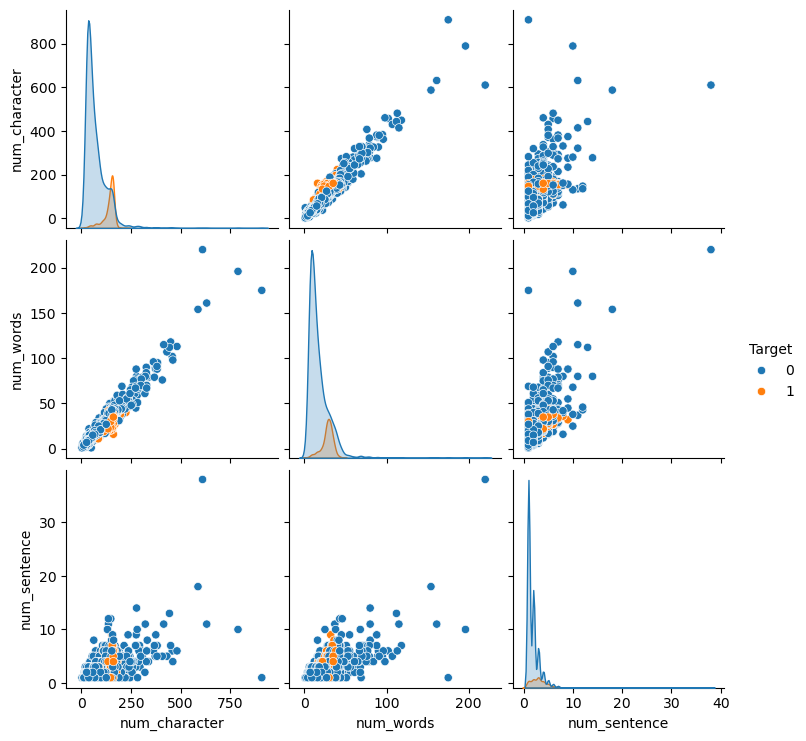

In [37]:
sns.pairplot(ds,hue='Target')
plt.show()

In [38]:
# corr=ds.corr()
# sns.heatmap(corr)

In [39]:
#Data Preprocessing

In [40]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [41]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [42]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('loving')

'love'

In [43]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():   #alphanumeric
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [44]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [45]:
ds['Text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [46]:
ds['Transform_Text']=ds['Text'].apply(transform_text)

In [47]:
ds.head()

,Target,Text,num_character,num_words,num_sentence,Transform_Text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [48]:
from wordcloud import WordCloud
wc=WordCloud(width=50,height=50,min_font_size=10,background_color='white')

In [49]:
# pip install wordcloud


In [50]:
spam_wc=wc.generate(ds[ds['Target']==1]['Transform_Text'].str.cat(sep=" "))

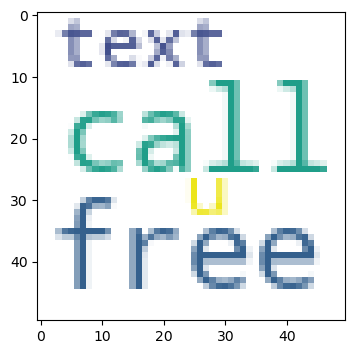

In [51]:
plt.figure(figsize=(8,4))
plt.imshow(spam_wc)
plt.show()

In [52]:
ham_wc=wc.generate(ds[ds['Target']==0]['Transform_Text'].str.cat(sep=" "))

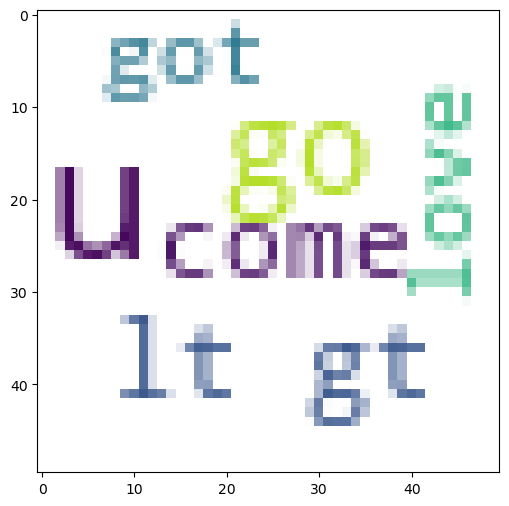

In [53]:
plt.figure(figsize=(18,6))
plt.imshow(ham_wc)
plt.show()

In [54]:
spam_corpus=[]
for msg in ds[ds['Target']==1]['Transform_Text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        

In [55]:
len(spam_corpus)

9939

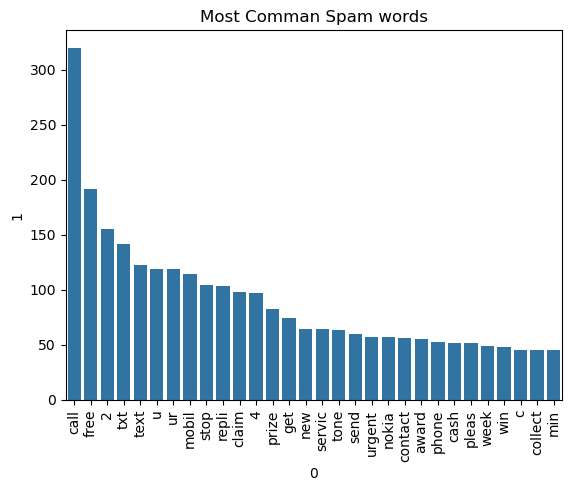

In [56]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.title("Most Comman Spam words")
plt.show()

In [57]:
ham_corpus=[]
for msg in ds[ds['Target']==0]['Transform_Text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
        

In [58]:
len(ham_corpus)

35404

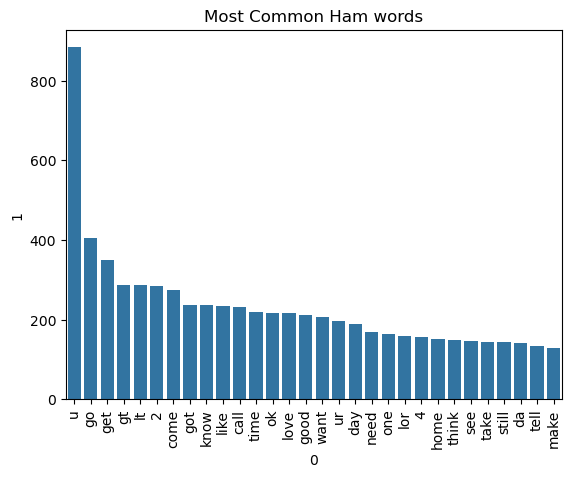

In [59]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.title("Most Common Ham words")
plt.show()

In [60]:
#Model Building

In [61]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
tfidf=TfidfVectorizer(max_features=3000)
cv=CountVectorizer()

In [62]:
# x=cv.fit_transform(ds['Transform_Text']).toarray()
x=tfidf.fit_transform(ds['Transform_Text']).toarray()

In [63]:
# from sklearn.preprocessing import MinMaxScaler
# scaler=MinMaxScaler()
# x=scaler.fit_transform(x)

In [64]:
x.shape

(5169, 3000)

In [65]:
y=ds['Target'].values

In [66]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [67]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [68]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [69]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [70]:
#For GuassianNB algo
gnb.fit(x_train,y_train)
y_pred=gnb.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))
      

0.8607350096711799
[[769 120]
 [ 24 121]]
0.5020746887966805


In [71]:
#for MultinomialNB
mnb.fit(x_train,y_train)
y_pred1=mnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9729206963249516
[[888   1]
 [ 27 118]]
0.9915966386554622


In [72]:
#for BernoulliNB
bnb.fit(x_train,y_train)
y_pred2=bnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9729206963249516
[[884   5]
 [ 23 122]]
0.9606299212598425


In [73]:
#Check Multiple algo for this model


In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [75]:
lsg=LogisticRegression(solver='liblinear',penalty='l1')
svc=SVC(kernel='sigmoid',gamma=1.0)
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
knc=KNeighborsClassifier()
rfc=RandomForestClassifier(n_estimators=50,random_state=2)

In [76]:
clfs={
    'SVC':svc,
    'MNB':mnb,
    'LSG':lsg,
    'DTC':dtc,
    'KNC':knc,
    'RFC':rfc
}

In [77]:
def transform_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred=clf.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)

    return accuracy,precision

In [78]:
transform_classifier(lsg,x_train,y_train,x_test,y_test)

(0.9468085106382979, 0.8688524590163934)

In [79]:
accuracy_scores=[]
precision_scores=[]
for name,clf in clfs.items():
    Caccuracy_score,Cprecision_score=transform_classifier(clf,x_train,y_train,x_test,y_test)
    print("Name:",name)
    print("Accuracy Score:",Caccuracy_score)
    print("Precision Score:",Cprecision_score)

    accuracy_scores.append(Caccuracy_score)
    precision_scores.append(Cprecision_score)

Name: SVC
Accuracy Score: 0.97678916827853
Precision Score: 0.9548872180451128
Name: MNB
Accuracy Score: 0.9729206963249516
Precision Score: 0.9915966386554622
Name: LSG
Accuracy Score: 0.9468085106382979
Precision Score: 0.8688524590163934
Name: DTC
Accuracy Score: 0.9332688588007737
Precision Score: 0.8275862068965517
Name: KNC
Accuracy Score: 0.9168278529980658
Precision Score: 1.0
Name: RFC
Accuracy Score: 0.971953578336557
Precision Score: 0.9754098360655737


In [80]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [81]:
performance_df

,Algorithm,Accuracy,Precision
4,KNC,0.916828,1.000000
1,MNB,0.972921,0.991597
5,RFC,0.971954,0.975410
0,SVC,0.976789,0.954887
2,LSG,0.946809,0.868852
3,DTC,0.933269,0.827586


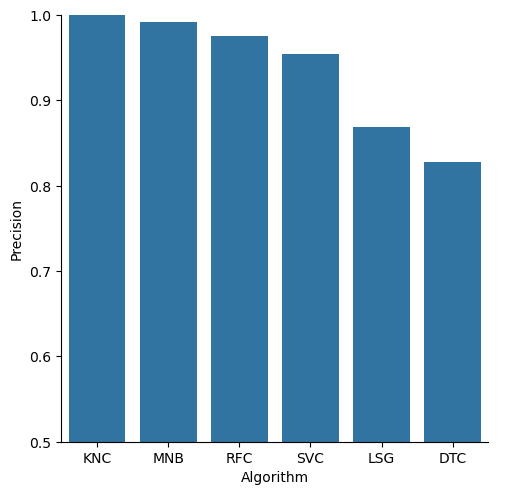

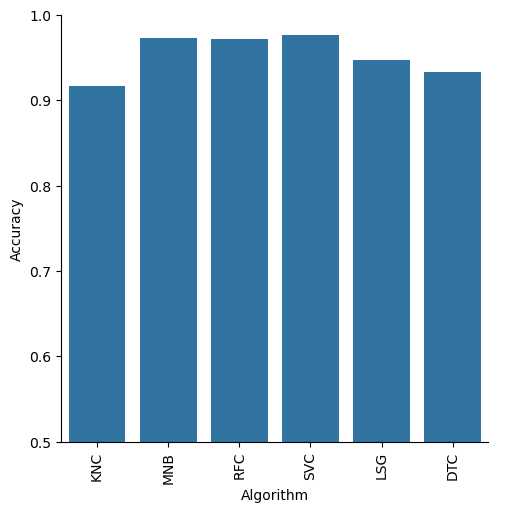

In [82]:
a=sns.catplot(x='Algorithm',y='Precision',data=performance_df,kind='bar',height=5)
plt.ylim(0.5,1.0)
b=sns.catplot(x='Algorithm',y='Accuracy',data=performance_df,kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [83]:
#model improvement
# 1.change The max feature in tfidf

In [84]:
#voting Classifier
knc=knc=KNeighborsClassifier()
mnb=MultinomialNB()
rfc=RandomForestClassifier(n_estimators=50,random_state=2)

In [85]:
from sklearn.ensemble import VotingClassifier
voting=VotingClassifier(estimators=[('KNC',knc),('MNB',mnb),('RFC',rfc)],voting='soft')

In [86]:
voting.fit(x_train,y_train)

VotingClassifier(estimators=[('KNC', KNeighborsClassifier()),
                             ('MNB', MultinomialNB()),
                             ('RFC',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=2))],
                 voting='soft')

In [87]:
mnb.fit(x_train,y_train)

MultinomialNB()

In [88]:
y_pred4=voting.predict(x_test)
print('Accuracy:',accuracy_score(y_test,y_pred4))#0.9680
print("Precision:",precision_score(y_test,y_pred4))#1.0

Accuracy: 0.9680851063829787
Precision: 1.0


In [89]:
# #applying Stacking
from sklearn.ensemble import StackingClassifier
slf=StackingClassifier(estimators=[('KNC',knc),('MNB',mnb),('RFC',rfc)],final_estimator=DecisionTreeClassifier(max_depth=5))

In [90]:
slf.fit(x_train,y_train)
y_pred5=voting.predict(x_test)
print('Accuracy:',accuracy_score(y_test,y_pred5))#0.9680
print("Precision:",precision_score(y_test,y_pred5))#1.0

Accuracy: 0.9680851063829787
Precision: 1.0


In [91]:
import pickle as pkl
pkl.dump(tfidf,open('Vectorizer.pkl','wb'))
pkl.dump(mnb,open('mnb.pkl','wb'))